# Summary statistics across volatility regimes

Builds the paper's summary-statistics numbers from the three per-regime modeling folders — `low_vol`
(Calm), `mid_vol` (Medium), `high_vol` (Turbulent) — reading only the parquets each already holds (no
Dune). All logic lives in `arblib.summary` / `arblib.reporting`; the cells are call-only. The rendered
tables and `to_latex()` dumps are meant to be copied into an LLM to produce the final LaTeX.

## Methodology

**Reference quantile.** q20 is the primary specification (smallest, least tick-crossing trade size, so
the round-trip spread stays cleanly interpretable). The main table describes the q20 sample; a compact
second table reports existence across all four quantiles as a robustness glance.

**Covariate means (sd) by regime** validate the regime construction: CEX EWMA volatility must rise
monotonically Calm → Medium → Turbulent (it is the classification variable); whether MEV, frequency
and tip scale with it is itself a result about the friction channels; base fee and gas utilization are
confound checks.

**Panel dimensions** describe the full unconditioned panel per window — before any `D==1` or risk-set
restriction. The N each model actually fits belongs in that model's own results table.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

from arblib import summary as sm, reporting as rp, plotting
from arblib.config import STUDY as S

# Load the three regime panels once (low = Calm, mid = Medium, high = Turbulent).
panels = sm.load_regime_panels(S)
{r: p.shape for r, p in panels.items()}

{'low': (645795, 27), 'mid': (430420, 27), 'high': (644940, 27)}

## Table 1 — main summary statistics (q20)

Panel dimensions, the q20 dependent-variable distribution conditional on a gap being open (`D==1`), and
covariate means (sd), one column per regime (Calm → Medium → Turbulent). `Gap` is in basis points;
base fee and priority-tip p90 in Gwei; CEX EWMA volatility scaled ×10⁻³ for legibility.

In [2]:
main = sm.summary_table(panels, S, quantile=0.2)
main

Calm                   Medium                Turbulent
Section                                  Metric                                                                                                    
Panel dimensions                         Window (UTC, inclusive)          2026-05-12 – 2026-05-17  2026-04-07 – 2026-04-12  2026-02-28 – 2026-03-05
                                         N obs (pool-pair × block)                        645,795                  430,420                  644,940
                                         N pool-pairs                                          15                       10                       15
                                         N blocks spanned                                  43,053                   43,042                   42,996
Dependent variable: Gap (bps), q20 | D=1 Existence rate, D=1 (%)                             11.2                     5.65                     4.82
                                         Mean Gap | D=1                                      32.4                    2.863                    5.071
                                         Median Gap | D=1                                   28.71                    1.706                    2.831
                                         p10 Gap | D=1                                      0.745                   0.2469                   0.3875
                                         p90 Gap | D=1                                      69.45                    6.112                    12.12
Covariates: mean (sd)                    Base fee (Gwei)                             0.473 (1.08)          0.1296 (0.0959)           0.1252 (0.169)
                                         Gas utilization                           0.5051 (0.201)           0.5063 (0.225)            0.507 (0.239)
                                         Priority fee p90 (Gwei)                     1.961 (2.95)             1.445 (3.27)             2.337 (22.9)
                                         MEV intensity (venue-avg log1p)             16.81 (3.67)             18.62 (2.22)                18 (4.46)
                                         Swap frequency (EWMA/block)               0.3798 (0.367)           0.6066 (0.571)            0.8075 (0.83)
                                         CEX EWMA volatility (×10⁻³)               0.4581 (0.275)           0.6574 (0.337)            1.159 (0.443)

## Table 2 — existence rate across reference quantiles

Share of pool-pair × block cells with a live executable gap (%) at each reference trade size, by
regime. Existence should collapse as the quantile grows — a larger reference trade crosses more ticks,
so fewer blocks host a clean round-trip gap.

In [3]:
existence_xq = sm.existence_cross_quantile_table(panels)
existence_xq

,Calm,Medium,Turbulent
Reference quantile,,,
q20,11.153,5.648,4.820
q40,4.629,2.050,1.513
q60,1.138,0.557,0.605
q80,0.102,0.115,0.128


## Copy-paste for LaTeX

Hand the rendered tables (or the `to_latex()` dumps below) plus the methodology notes to an LLM to
produce the final table `tab:summary-stats`.

In [4]:
print(main.to_latex())
print()
print(existence_xq.to_latex(float_format="%.3f"))

\begin{tabular}{lllll}
\toprule
 &  & Calm & Medium & Turbulent \\
Section & Metric &  &  &  \\
\midrule
\multirow[t]{4}{*}{Panel dimensions} & Window (UTC, inclusive) & 2026-05-12 – 2026-05-17 & 2026-04-07 – 2026-04-12 & 2026-02-28 – 2026-03-05 \\
 & N obs (pool-pair × block) & 645,795 & 430,420 & 644,940 \\
 & N pool-pairs & 15 & 10 & 15 \\
 & N blocks spanned & 43,053 & 43,042 & 42,996 \\
\cline{1-5}
\multirow[t]{5}{*}{Dependent variable: Gap (bps), q20 | D=1} & Existence rate, D=1 (%) & 11.2 & 5.65 & 4.82 \\
 & Mean Gap | D=1 & 32.4 & 2.863 & 5.071 \\
 & Median Gap | D=1 & 28.71 & 1.706 & 2.831 \\
 & p10 Gap | D=1 & 0.745 & 0.2469 & 0.3875 \\
 & p90 Gap | D=1 & 69.45 & 6.112 & 12.12 \\
\cline{1-5}
\multirow[t]{6}{*}{Covariates: mean (sd)} & Base fee (Gwei) & 0.473 (1.08) & 0.1296 (0.0959) & 0.1252 (0.169) \\
 & Gas utilization & 0.5051 (0.201) & 0.5063 (0.225) & 0.507 (0.239) \\
 & Priority fee p90 (Gwei) & 1.961 (2.95) & 1.445 (3.27) & 2.337 (22.9) \\
 & MEV intensity (venue-avg l

# Regime × quantile regression tables

The three block-level models — onset hazard (logit), closure hazard (logit), and magnitude (within
pool-pair FE OLS) — refit for every regime and both lead quantiles (q20, q40), one coefficient table
each. Same recipes as notebooks 06 / 07 / 08; `arblib.reporting` loops them over the regimes, reading
each regime's panel from its own `<regime>_vol` folder — so nothing depends on `STUDY.active_regime`.

Each cell is the coefficient with significance stars (`***` p<0.01, `**` p<0.05, `*` p<0.10); trailing
columns are the fit's pseudo / within R², N, and the pool-pair count after the constant-`D` and
events-per-variable screens. Fitting all 18 models takes ~30–40 s.

## Table `tab:onset` — onset hazard (logit)

Risk set `gap_lag == 0`; dependent variable `D = 1[Gap>0]` (a gap *appears* at t). LSDV with
pool-pair and hour-of-day fixed effects, pair-clustered SEs; pseudo R² is McFadden's. `N` = risk-set
observations; `N_pairs` = pool-pairs retained after dropping constant-`D` pairs and the EPV floor.


In [5]:
onset = rp.onset_table(panels, S, quantiles=(0.2, 0.4))
onset

log base fee_t gas util_{t-1} tip p90_{t-1} MEV_{t-1} freq_{t-1}   log σ_t  pseudo R²       N  N_pairs
Regime    q                                                                                                         
Calm      q20        0.276**      -0.390***        -0.015     0.042      0.232  0.861***     0.2308  365731       10
          q40       0.378***      -0.365***        -0.005     0.041    0.440**  0.831***     0.2029  282600        7
Medium    q20       0.438***      -0.396***         0.000  0.161***   0.431***  0.490***     0.2567  319928        8
          q40       0.629***      -0.436***        -0.014  0.172***   0.449***  0.525***     0.1742  292440        7
Turbulent q20       0.493***      -0.369***        -0.021  0.184***   0.389***  0.583***     0.2607  484708       12
          q40       0.482***      -0.462***      -0.044**  0.179***   0.397***  0.945***     0.1980  420144       10

## Table `tab:closure` — closure hazard (logit)

Risk set `gap_lag > 0` (a gap is open at t-1); dependent variable `D = 1` if the gap *survives* to
block t, conditional on `D_{t-1}=1`. Adds spell age (`spell dur.`) and the open-gap size
`log(1+gap_{t-1})`. Same fixed effects / pair-clustered SEs / pseudo R² as the onset table.


In [6]:
closure = rp.closure_table(panels, S, quantiles=(0.2, 0.4))
closure

log base fee_t gas util_{t-1} tip p90_{t-1}  MEV_{t-1} freq_{t-1}    log σ_t spell dur. log(1+gap_{t-1})  pseudo R²      N  N_pairs
Regime    q                                                                                                                                      
Calm      q20       0.405***       0.235***         0.019  -0.203***  -0.307***     -0.168   0.003***         0.368***     0.4272  64629       10
          q40       0.474***        0.252**        0.042*  -0.097***  -0.397***   -0.145**   0.011***          0.179**     0.2082  18652        7
Medium    q20       0.590***          0.036         0.006  -0.042***   -0.116**  -0.179***   0.026***            0.061     0.0859  23959        5
          q40       0.683***       -0.190**      -0.026**  -0.055***     -0.072    -0.125*    0.064**           0.040*     0.0732   8576        5
Turbulent q20       0.505***          0.033       -0.012*  -0.044***      0.039     -0.109   0.025***         0.167***     0.1204  30867       11
          q40       0.327***         -0.076     -0.019***     -0.024   0.139***     0.286*   0.077***         0.155***     0.1067   9476        9

## Table `tab:magnitude` — magnitude (within pool-pair FE OLS)

Conditional on existence (`D == 1`); dependent variable `log Gap`. Pool-pair fixed effects swept out
by the within transformation (**no** hour effects), two-way (pool-pair × block) clustered SEs. Within
R² is reported (Between / Overall R² are unreliable on this unbalanced, few-entity panel). `N` =
`D==1` observations after the minimum-rows-per-pair floor.


In [7]:
mag = rp.magnitude_table(panels, S, quantiles=(0.2, 0.4))
mag

log base fee_t gas util_{t-1} tip p90_{t-1} MEV_{t-1} freq_{t-1}   log σ_t log(1+gap_{t-1})  within R²      N  N_pairs
Regime    q                                                                                                                         
Calm      q20          0.052         -0.020         0.001   -0.012*   0.138***     0.060         0.995***     0.5998  71957       12
          q40        0.089**         -0.053         0.002     0.007   0.083***  0.246***         0.934***     0.4919  29837       12
Medium    q20       0.248***        -0.126*         0.006   0.026**   0.220***  0.147***         0.480***     0.1463  24292        8
          q40         0.090*        -0.151*         0.016  0.049***   0.276***  0.223***         0.344***     0.1096   8753        7
Turbulent q20          0.090      -0.142***        -0.010   0.024**   0.151***  0.456***         0.442***     0.1835  31034       12
          q40        -0.080*         -0.074        -0.007  0.079***   0.132***  0.543***         0.328***     0.0920   9643       10

## Copy-paste for LaTeX

`to_latex()` for all three coefficient tables — hand these (with the paper captions) to an LLM to
slot into the `tab:onset` / `tab:closure` / `tab:magnitude` layouts. The `\multirow` regime grouping
and `\shortstack` column heads are cosmetic; the numbers are what matter.


In [8]:
for name, tbl in [("onset", onset), ("closure", closure), ("magnitude", mag)]:
    print(f"% ===== {name} =====")
    print(tbl.to_latex())
    print()

% ===== onset =====
\begin{tabular}{llllllllrrr}
\toprule
 &  & log base fee_t & gas util_{t-1} & tip p90_{t-1} & MEV_{t-1} & freq_{t-1} & log σ_t & pseudo R² & N & N_pairs \\
Regime & q &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{Calm} & q20 & 0.276** & -0.390*** & -0.015 & 0.042 & 0.232 & 0.861*** & 0.230800 & 365731 & 10 \\
 & q40 & 0.378*** & -0.365*** & -0.005 & 0.041 & 0.440** & 0.831*** & 0.202900 & 282600 & 7 \\
\cline{1-11}
\multirow[t]{2}{*}{Medium} & q20 & 0.438*** & -0.396*** & 0.000 & 0.161*** & 0.431*** & 0.490*** & 0.256700 & 319928 & 8 \\
 & q40 & 0.629*** & -0.436*** & -0.014 & 0.172*** & 0.449*** & 0.525*** & 0.174200 & 292440 & 7 \\
\cline{1-11}
\multirow[t]{2}{*}{Turbulent} & q20 & 0.493*** & -0.369*** & -0.021 & 0.184*** & 0.389*** & 0.583*** & 0.260700 & 484708 & 12 \\
 & q40 & 0.482*** & -0.462*** & -0.044** & 0.179*** & 0.397*** & 0.945*** & 0.198000 & 420144 & 10 \\
\cline{1-11}
\bottomrule
\end{tabular}


% ===== closure =====
\begin{tabular}{lll

# Regressor correlation heatmaps, by regime

Pearson correlation among the block-level model regressors (the covariates in the tables above),
computed over the full q20 model frame, one heatmap per regime on a shared [−1, 1] scale.

This is the multicollinearity read: the environment covariates are only mildly correlated, the
strongest pairs being base fee ↔ log σ and MEV ↔ freq; gas util and tip p90 are near-orthogonal.
`log(1+gap_{t-1})` and `spell dur.` are lagged-state terms that are 0 off-spell, so their mutual
correlation is mechanical rather than economic.

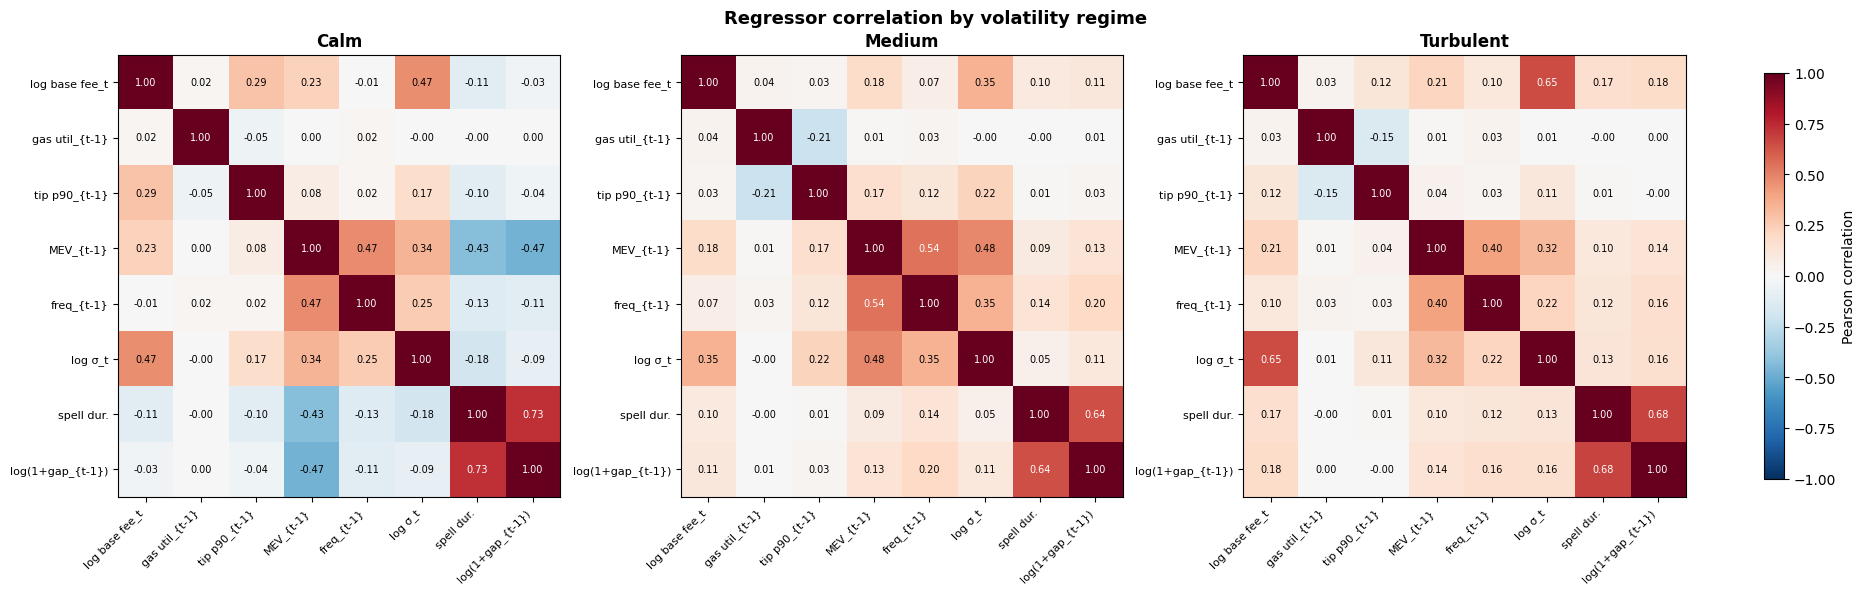

In [9]:
corr_by_regime = rp.covariate_correlations(panels, quantile=0.2)
plotting.plot_correlation_heatmaps(corr_by_regime)

The numeric matrices are in `corr_by_regime` (keyed `"Calm"` / `"Medium"` / `"Turbulent"`)
if you want to drop the values into the paper — e.g. `corr_by_regime["Turbulent"].round(2)`.
